# 🎬 پروژه GraphRAG برای پیشنهاد و تحلیل فیلم
### اجرای کامل در Google Colab — از صفر تا صد

این نوت‌بوک به‌ترتیب انجام می‌دهد:
1. نصب و راه‌اندازی Neo4j روی خود ماشین Colab
2. نصب کتابخانه‌های پایتون لازم
3. آپلود دیتاست‌های TMDB و IMDB
4. پردازش و تمیزکاری داده‌ها
5. ساخت گراف دانش (Knowledge Graph) در Neo4j
6. نمایش بصری نمونه‌ای از گراف ساخته‌شده
7. نوشتن و اجرای اسکریپت CLI مبتنی بر GraphRAG (با لایه‌ی مدل دیفیوژن)

⚠️ **مهم:** سلول‌ها را دقیقاً به‌ترتیب از بالا به پایین اجرا کنید. هر سلول در انتها یک گزارش وضعیت چاپ می‌کند — قبل از رفتن به سلول بعد، از موفقیت‌آمیز بودن آن (علامت ✅) مطمئن شوید.

**پیش‌نیاز:** `Runtime → Change runtime type → GPU (T4)` را از قبل انتخاب کرده باشید.


## بخش ۰: بررسی GPU و تنظیمات کلی پروژه

In [1]:
!nvidia-smi


Wed Jul 29 05:53:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ============================================================
# بررسی اجباری GPU — قبل از ادامه، مطمئن می‌شویم واقعاً به GPU وصل هستیم.
# مدل دیفیوژن ۸ میلیاردی روی CPU عملاً غیرقابل‌اجراست، پس اگر همین الان GPU نباشد،
# بهتر است همین‌جا متوقف شویم تا ۱۵-۲۰ دقیقهٔ بعدی (نصب، آپلود دیتاست، ساخت گراف) را
# بیهوده صرف نکنید و فقط در آخرین قدم بفهمید GPU وصل نبوده.
# ============================================================
import subprocess

gpu_check = subprocess.run(["nvidia-smi"], capture_output=True, text=True)

if gpu_check.returncode != 0:
    raise RuntimeError(
        "\n\n"
        "🛑 GPU وصل نیست! قبل از ادامه این را انجام دهید:\n"
        "   1) از منو: Runtime > Change runtime type\n"
        "   2) زیر Hardware accelerator: گزینهٔ T4 GPU را انتخاب کنید (نه None)\n"
        "   3) Save بزنید و اتصال مجدد رانتایم را تأیید کنید\n"
        "   4) این سلول را دوباره اجرا کنید\n\n"
        "اگر بعد از انتخاب GPU باز هم این خطا را دیدید، احتمالاً سهمیهٔ رایگان GPU "
        "روزانه‌ی حساب Colab شما تمام شده — چند ساعت صبر کنید یا از حساب/Colab Pro "
        "دیگری استفاده کنید.\n"
    )
else:
    print("✅ GPU متصل است — می‌توانید با خیال راحت ادامه دهید.")
    print(gpu_check.stdout.split(chr(10))[8] if len(gpu_check.stdout.split(chr(10))) > 8 else "")


✅ GPU متصل است — می‌توانید با خیال راحت ادامه دهید.
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


In [3]:
# ============================================================
# تنظیمات کلی پروژه — این مقادیر در چند سلول بعدی استفاده می‌شوند
# ============================================================

NEO4J_PASSWORD_COLAB = "Colab.Password123"   # دلخواه است، می‌توانید عوض کنید

# اگر GPU ندارید یا اصلاً نمی‌خواهید مدل دیفیوژن لود شود، این را False کنید.
DIFFUSION_ENABLED_COLAB = True

# STRICT MODE: اگر True باشد، هر شکستی در لود/اجرای مدل دیفیوژن به‌جای سقوط بی‌صدا
# به پاسخ الگو-محور، یک خطای صریح می‌دهد (مفید برای دیباگ — دقیقاً می‌فهمید مشکل
# کجاست). برای اجرای نهایی/دمو که نباید کل CLI متوقف شود، این را False بگذارید.
STRICT_DIFFUSION_MODE_COLAB = True

print("✅ تنظیمات پروژه مقداردهی شد.")
print(f"   NEO4J_PASSWORD_COLAB         = {NEO4J_PASSWORD_COLAB}")
print(f"   DIFFUSION_ENABLED_COLAB      = {DIFFUSION_ENABLED_COLAB}")
print(f"   STRICT_DIFFUSION_MODE_COLAB  = {STRICT_DIFFUSION_MODE_COLAB}")


✅ تنظیمات پروژه مقداردهی شد.
   NEO4J_PASSWORD_COLAB         = Colab.Password123
   DIFFUSION_ENABLED_COLAB      = True
   STRICT_DIFFUSION_MODE_COLAB  = True


## بخش ۱: نصب و راه‌اندازی Neo4j

In [4]:
%%bash
# رفع باگ: اگر این سلول دوباره اجرا شود (مثلاً بعد از یک خطا در سلول‌های بعدی)،
# نسخهٔ قبلی mv/tar باعث خطای "File exists" می‌شد چون /opt/neo4j را از قبل ساخته بود.
# حالا قبل از نصب مجدد بررسی می‌کنیم که آیا قبلاً نصب شده یا نه.
if [ -d /opt/neo4j ]; then
    echo "✅ Neo4j از قبل نصب شده — نصب مجدد رد شد."
else
    apt-get update -qq
    apt-get install -y openjdk-17-jdk -qq
    wget -q https://dist.neo4j.org/neo4j-community-5.22.0-unix.tar.gz
    tar -xzf neo4j-community-5.22.0-unix.tar.gz
    mv neo4j-community-5.22.0 /opt/neo4j
    echo "✅ نصب Neo4j تمام شد"
fi


Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected package at-spi2-core.
Preparing to unpack .../04-at-spi2-core_2.44.0-3_amd64.deb ...
Unpacking at-spi2-core (2.44.0-3) ...
Selecting previously unselected package fonts-dejavu-core.
Prepar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

result = os.system(
    f'/opt/neo4j/bin/neo4j-admin dbms set-initial-password "{NEO4J_PASSWORD_COLAB}"'
)
if result == 0:
    print(f"✅ رمز عبور Neo4j با موفقیت تنظیم شد: {NEO4J_PASSWORD_COLAB}")
else:
    print("❌ تنظیم رمز عبور ناموفق بود — لاگ بالا را بررسی کنید.")


✅ رمز عبور Neo4j با موفقیت تنظیم شد: Colab.Password123


In [6]:
import subprocess, time, urllib.request, json

neo4j_proc = subprocess.Popen(
    ["/opt/neo4j/bin/neo4j", "console"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

print("⏳ در حال بالا آمدن Neo4j...")

up = False
for attempt in range(15):
    time.sleep(3)
    try:
        with urllib.request.urlopen("http://localhost:7474", timeout=3) as resp:
            info = json.loads(resp.read().decode())
            up = True
            break
    except Exception:
        continue

if up:
    print("✅ Neo4j با موفقیت بالا آمد.")
    print(f"   نسخه: {info.get('neo4j_version')} | نوع: {info.get('neo4j_edition')}")
    print(f"   Bolt endpoint: {info.get('bolt_direct')}")
else:
    print("❌ Neo4j بعد از ۴۵ ثانیه بالا نیامد. سلول‌های بخش ۱ را از اول اجرا کنید "
          "(Runtime > Restart session را هم امتحان کنید).")


⏳ در حال بالا آمدن Neo4j...
✅ Neo4j با موفقیت بالا آمد.
   نسخه: 5.22.0 | نوع: community
   Bolt endpoint: bolt://localhost:7687


## بخش ۲: نصب کتابخانه‌های پایتون\n\n⚠️ نکات مهم:\n1. عمداً `torch`/`torchvision` نصب یا آپدیت نمی‌شوند.\n2. `transformers` روی نسخهٔ دقیق **۴.۳۸.۲** ثابت می‌شود (الزام مخزن رسمی LLaDA).\n3. **جدید:** `accelerate` و `bitsandbytes` هم به نسخه‌های هم‌دورانِ transformers ۴.۳۸.۲ (اوایل ۲۰۲۴) پین شدند. علت واقعی خطای `.to is not supported for 4-bit models` که تکرار می‌شد، ناسازگاری بین transformers قدیمی و accelerate/bitsandbytes بسیار جدید بود (نه sentence-transformers — آن فقط یک هشدار بی‌خطر و نامرتبط pip بود، در ادامه توضیح می‌دهم چرا).\n4. **جدید:** `spaCy` + مدل `en_core_web_sm` هم اضافه شد تا نام بازیگر/کارگردان را با تشخیص موجودیت نام (NER) به‌جای فقط الگوریتم fuzzy matching شناسایی کند.

In [7]:
# نکته: هشدار pip دربارهٔ sentence-transformers (اگر ببینید) بی‌خطر است — این
# کتابخانه اصلاً در پروژهٔ ما استفاده/ایمپورت نمی‌شود؛ فقط از قبل روی ایمیج پایهٔ
# Colab نصب است و pip's dependency resolver دربارهٔ نسخهٔ آن هشدار می‌دهد، اما
# transformers==4.38.2 هرگز عملاً override نمی‌شود (در گزارش پایین همین سلول تأیید
# می‌شود).
#
# رفع باگ (جدید): پین قبلی bitsandbytes==0.42.0 روی ایمیج فعلی Colab با خطای
# «CUDA Setup failed despite GPU being available» کرش می‌کند. علتش این نیست که
# GPU یا CUDA واقعاً مشکل دارد؛ نسخهٔ ۰.۴۲ از یک ماژول قدیمی و شکننده به اسم
# cuda_setup استفاده می‌کند که مسیرهای هارد-کدشدهٔ کتابخانه‌های libcudart.so را
# می‌گردد و روی چیدمان جدید CUDA در ایمیج‌های اخیر Colab (که از زمان اوایل ۲۰۲۴
# که این نسخه پین شده بود عوض شده) آن‌ها را پیدا نمی‌کند و RuntimeError می‌دهد؛
# این یک باگ شناخته‌شده و بسته‌شدهٔ خود پروژهٔ bitsandbytes است، نه مشکلی در این
# نوت‌بوک. از نسخهٔ ۰.۴۳ به بعد کل تشخیص CUDA بازنویسی شده (دیگر آن ماژول شکننده
# را ندارد) و مستقیماً از اطلاعات CUDA خودِ torch استفاده می‌کند، پس اینجا
# bitsandbytes به >=0.43.1 آپدیت شد. accelerate هم به نسخهٔ هم‌دورانِ آن (۰.۳۰.۱)
# آپدیت شد تا دوباره APIهای ناسازگار کنار هم قرار نگیرند. transformers همچنان
# دقیقاً روی ۴.۳۸.۲ ثابت می‌ماند (الزام مخزن رسمی LLaDA). اگر همین ترکیب باز هم
# همان خطای قدیمی «.to is not supported for 4-bit models» را برگرداند، منطق
# retry دوتلاشی که از قبل در DiffusionResponder._lazy_load وجود دارد
# (low_cpu_mem_usage=True سپس False) به‌طور خودکار آن را دور می‌زند.
!pip install -q neo4j rapidfuzz ddgs "transformers==4.38.2" "accelerate==0.30.1" "bitsandbytes>=0.43.1" sentencepiece einops psutil spacy
!python -m spacy download en_core_web_sm -q

import importlib
packages = ["neo4j", "rapidfuzz", "ddgs", "transformers", "accelerate", "bitsandbytes", "torch", "spacy"]
print("گزارش نصب کتابخانه‌ها:")
all_ok = True
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "نامشخص")
        print(f"  ✅ {pkg:15s} نسخه: {ver}")
    # رفع باگ: bitsandbytes روی محیط ناسازگار به‌جای ImportError یک RuntimeError
    # (از داخل cextension.py) پرتاب می‌کند و کل سلول/کرنل را با آن متوقف می‌کرد.
    # گرفتن Exception عمومی به‌جای فقط ImportError باعث می‌شود این گزارش برای
    # هر کتابخانه، مستقل از نوع خطا، ادامه پیدا کند و مشکل واقعی چاپ شود.
    except Exception as e:
        print(f"  ❌ {pkg:15s} ایمپورت نشد! ({type(e).__name__}: {e})")
        all_ok = False

import spacy
try:
    _nlp_check = spacy.load("en_core_web_sm")
    print("  ✅ مدل spaCy en_core_web_sm با موفقیت لود شد.")
except OSError:
    print("  ❌ مدل spaCy en_core_web_sm دانلود نشد — سلول را دوباره اجرا کنید.")
    all_ok = False

try:
    import transformers, accelerate, bitsandbytes
    version_checks = [
        ("transformers", transformers.__version__, "4.38.2"),
        ("accelerate", accelerate.__version__, "0.30.1"),
        ("bitsandbytes", bitsandbytes.__version__, "0.43.1"),
    ]
    mismatch = False
    for name, actual, expected in version_checks:
        # رفع باگ: bitsandbytes با ">=" پین شده، پس ممکن است نسخه‌ای *جدیدتر* از
        # 0.43.1 نصب شود که کاملاً طبیعی و بی‌خطر است؛ فقط نسخهٔ *قدیمی‌تر* (که
        # همان باگ CUDA Setup را دارد) باید هشدار بدهد.
        if name == "bitsandbytes":
            actual_tuple = tuple(int(p) for p in actual.split(".")[:2])
            if actual_tuple < (0, 43):
                print(f"\n⚠️ نسخهٔ bitsandbytes نصب‌شده ({actual}) قدیمی‌تر از ۰.۴۳ "
                      f"است — همان باگ CUDA Setup ممکن است دوباره رخ دهد.")
                mismatch = True
            continue
        if actual != expected:
            print(f"\n⚠️ نسخهٔ {name} نصب‌شده ({actual}) دقیقاً {expected} نیست — ممکن "
                  f"است لود مدل دیفیوژن (بخش ۸) شکست بخورد.")
            mismatch = True
    if mismatch:
        print("راه‌حل: Runtime > Restart session بزنید و این سلول را دوباره اجرا کنید.")
    else:
        print(f"\n✅ transformers/accelerate/bitsandbytes روی نسخه‌های سازگار و "
              f"هم‌دوران با LLaDA نصب شدند.")
except Exception as e:
    # رفع باگ: قبلاً اگر همین import در این‌جا (بار دوم، برای version_checks) با
    # RuntimeError کرش می‌کرد، هیچ‌کدام از چاپ‌های بعدی این سلول (وضعیت GPU و
    # خلاصهٔ نهایی) اجرا نمی‌شدند. الان خطا گرفته و گزارش می‌شود، و اجرای سلول
    # ادامه پیدا می‌کند.
    print(f"\n❌ بررسی نسخهٔ transformers/accelerate/bitsandbytes با خطا مواجه شد: "
          f"{type(e).__name__}: {e}")
    all_ok = False

import torch
print(f"\n  GPU در دسترس: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  نام GPU: {torch.cuda.get_device_name(0)}")

print("\n✅ همه کتابخانه‌ها نصب شدند." if all_ok else "\n⚠️ برخی کتابخانه‌ها نصب نشدند، لاگ بالا را ببینید.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

## بخش ۳: آپلود دیتاست‌های فیلم\n\nسه فایل زیر را از مکبوک خود انتخاب و آپلود کنید:\n- `tmdb_5000_movies.csv`\n- `tmdb_5000_credits.csv`\n- `imdb_top_1000.csv`\n\nبدون این فایل‌ها گراف دانش خالی می‌ماند و کل پروژه فقط از جستجوی وب استفاده می‌کند.

In [8]:
from google.colab import files
import os

os.makedirs("datasets", exist_ok=True)
print("لطفاً فایل‌های tmdb_5000_movies.csv ، tmdb_5000_credits.csv و imdb_top_1000.csv را انتخاب کنید:")
uploaded = files.upload()

for fname in uploaded:
    os.rename(fname, f"datasets/{fname}")

required_files = ["tmdb_5000_movies.csv", "tmdb_5000_credits.csv", "imdb_top_1000.csv"]
print("\nگزارش فایل‌های آپلودشده:")
missing = []
for f in required_files:
    path = f"datasets/{f}"
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  ✅ {f}  ({size_mb:.2f} مگابایت)")
    else:
        print(f"  ❌ {f}  — پیدا نشد!")
        missing.append(f)

if missing:
    print(f"\n⚠️ فایل‌های زیر آپلود نشدند، سلول را دوباره اجرا کنید و همه را انتخاب کنید: {missing}")
else:
    print("\n✅ همه دیتاست‌ها با موفقیت آپلود شدند.")


لطفاً فایل‌های tmdb_5000_movies.csv ، tmdb_5000_credits.csv و imdb_top_1000.csv را انتخاب کنید:


Saving imdb_top_1000.csv to imdb_top_1000.csv
Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv

گزارش فایل‌های آپلودشده:
  ✅ tmdb_5000_movies.csv  (5.43 مگابایت)
  ✅ tmdb_5000_credits.csv  (38.19 مگابایت)
  ✅ imdb_top_1000.csv  (0.42 مگابایت)

✅ همه دیتاست‌ها با موفقیت آپلود شدند.


## بخش ۴: پردازش و تمیزکاری داده‌ها

In [9]:
import pandas as pd
import ast

movies = pd.read_csv('datasets/tmdb_5000_movies.csv')
credits = pd.read_csv('datasets/tmdb_5000_credits.csv')

tmdb = movies.merge(credits, on="title")
tmdb = tmdb[['title', 'genres', 'cast', 'crew', 'release_date']]

print(f"✅ merge اولیه انجام شد — تعداد سطرها: {len(tmdb)}")
tmdb.head(3)


✅ merge اولیه انجام شد — تعداد سطرها: 4809


,title,genres,cast,crew,release_date
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009-12-10
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007-05-19
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015-10-26


In [10]:
def get_director(crew):
    try:
        crew = ast.literal_eval(crew)
        for person in crew:
            if person['job'] == 'Director':
                return person['name']
    except Exception:
        pass
    return None

def get_cast(cast):
    try:
        cast = ast.literal_eval(cast)
        return [actor['name'] for actor in cast[:5]]
    except Exception:
        return []

def extract_names(text):
    try:
        text = ast.literal_eval(text)
        return [item['name'] for item in text]
    except Exception:
        return []

tmdb['director'] = tmdb['crew'].apply(get_director)
tmdb['actors'] = tmdb['cast'].apply(get_cast)
tmdb['genres'] = tmdb['genres'].apply(extract_names)
tmdb['year'] = pd.to_datetime(tmdb['release_date'], errors='coerce').dt.year.astype('Int64')
tmdb = tmdb.drop(columns=['cast', 'crew', 'release_date'])

print("✅ استخراج director/actors/genres/year انجام شد.")
print(f"   تعداد فیلم‌های بدون کارگردان مشخص: {tmdb['director'].isna().sum()}")
print(f"   تعداد فیلم‌های بدون سال مشخص: {tmdb['year'].isna().sum()}")
tmdb.head(3)


✅ استخراج director/actors/genres/year انجام شد.
   تعداد فیلم‌های بدون کارگردان مشخص: 30
   تعداد فیلم‌های بدون سال مشخص: 1


,title,genres,director,actors,year
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",James Cameron,"[Sam Worthington, Zoe Saldana, Sigourney Weave...",2009
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",Gore Verbinski,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...",2007
2,Spectre,"[Action, Adventure, Crime]",Sam Mendes,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",2015


In [11]:
imdb = pd.read_csv('datasets/imdb_top_1000.csv')

# رفع باگ KeyError: نسخهٔ رایج و پرکاربرد این دیتاست در Kaggle (harshitshankhdhar)
# از نام ستون‌های Series_Title / Released_Year / IMDB_Rating / Star1..Star4 استفاده
# می‌کند، نه title/year/imdb_rating/actor1..actor4 که کد قبلی مستقیماً فرض کرده بود
# و همیشه با KeyError کرش می‌کرد. این‌جا نگاشت را فقط برای ستون‌هایی که واقعاً با
# نام قدیمی موجودند اعمال می‌کنیم تا اگر کاربر نسخهٔ دیگری از فایل با نام ستون‌های
# از قبل درست آپلود کرده، دست‌نخورده بماند.
column_rename_map = {
    "Series_Title": "title",
    "Released_Year": "year",
    "IMDB_Rating": "imdb_rating",
    "Star1": "actor1",
    "Star2": "actor2",
    "Star3": "actor3",
    "Star4": "actor4",
}
imdb = imdb.rename(columns={k: v for k, v in column_rename_map.items() if k in imdb.columns})

required_imdb_cols = ["title", "year", "imdb_rating", "actor1", "actor2", "actor3", "actor4"]
missing_cols = [c for c in required_imdb_cols if c not in imdb.columns]
if missing_cols:
    raise KeyError(
        f"ستون‌های زیر در imdb_top_1000.csv پیدا نشدند: {missing_cols}. "
        f"ستون‌های موجود در فایل شما: {list(imdb.columns)}"
    )

imdb['actors_imdb'] = imdb[['actor1', 'actor2', 'actor3', 'actor4']].values.tolist()
# رفع باگ: در همین دیتاست شناخته‌شده، چند ردیف به‌خاطر خطای اسکرِیپ اصلی، مقداری
# غیرعددی (مثلاً یک Certificate) داخل ستون سال دارند؛ errors='coerce' آن‌ها را
# NaN می‌کند به‌جای این‌که کل سلول را با ValueError متوقف کند.
imdb['year'] = pd.to_numeric(imdb['year'], errors='coerce').astype('Int64')
imdb = imdb[['title', 'year', 'imdb_rating']]

final_data = tmdb.merge(imdb, on=['title', 'year'], how='left')
final_data = final_data[['title', 'genres', 'actors', 'director', 'year', 'imdb_rating']]

print(f"✅ merge نهایی با IMDB انجام شد.")
print(f"   شکل نهایی دیتاست: {final_data.shape}")
print(f"   تعداد فیلم‌هایی که امتیاز IMDB پیدا کردند: {final_data['imdb_rating'].notna().sum()} از {len(final_data)}")
final_data.head(5)


✅ merge نهایی با IMDB انجام شد.
   شکل نهایی دیتاست: (4809, 6)
   تعداد فیلم‌هایی که امتیاز IMDB پیدا کردند: 426 از 4809


,title,genres,actors,director,year,imdb_rating
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",James Cameron,2009,7.8
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Gore Verbinski,2007,NaN
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Sam Mendes,2015,NaN
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[Christian Bale, Michael Caine, Gary Oldman, A...",Christopher Nolan,2012,8.4
4,John Carter,"[Action, Adventure, Science Fiction]","[Taylor Kitsch, Lynn Collins, Samantha Morton,...",Andrew Stanton,2012,NaN


## بخش ۵: ساخت گراف دانش در Neo4j\n\nاین سلول ممکن است چند دقیقه طول بکشد (برای ~۵۰۰۰ فیلم). صبر کنید تا گزارش نهایی چاپ شود.

In [12]:
from neo4j import GraphDatabase
import time

NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"

class MovieGraph:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def close(self):
        self.driver.close()

    def add_movies(self, df, report_every=500):
        with self.driver.session() as session:
            start = time.time()
            for i, (_, row) in enumerate(df.iterrows()):
                genres = row['genres'] if isinstance(row['genres'], list) and row['genres'] else ['none']
                actors = row['actors'] if isinstance(row['actors'], list) and row['actors'] else ['none']

                director = row['director']
                if pd.isna(director) or director is None:
                    director = "none"

                title = row['title']
                if pd.isna(title) or title is None:
                    title = "Unknown Movie"

                year = row['year']
                year = 0 if pd.isna(year) else int(year)

                imdb_rating = row['imdb_rating']
                imdb_rating = 0.0 if pd.isna(imdb_rating) else float(imdb_rating)

                session.execute_write(
                    self._create_full_movie, title, year, imdb_rating, genres, actors, director
                )

                if (i + 1) % report_every == 0:
                    elapsed = time.time() - start
                    print(f"  ... {i + 1}/{len(df)} فیلم پردازش شد ({elapsed:.0f} ثانیه سپری شده)")

    @staticmethod
    def _create_full_movie(tx, title, year, rating, genres, actors, director):
        tx.run("MERGE (m:Movie {title: $title})", title=title)

        tx.run("""
            MERGE (y:Year {year: $year})
            WITH y
            MATCH (m:Movie {title: $title})
            MERGE (m)-[:IN_YEAR]->(y)
        """, year=year, title=title)

        rating_int = int(rating)
        tx.run("""
            MERGE (rating:RATING {rating: $rating_int})
            WITH rating
            MATCH (m:Movie {title: $title})
            MERGE (m)-[r:WITH_POINTS]->(rating)
            SET r.real_rating = $rating
        """, title=title, rating=rating, rating_int=rating_int)

        for g in genres:
            tx.run("""
                MERGE (genre:Genre {name: $g})
                WITH genre
                MATCH (m:Movie {title: $title})
                MERGE (m)-[:HAS_GENRE]->(genre)
            """, g=g, title=title)

        for a in actors:
            tx.run("""
                MERGE (actor:Actor {name: $a})
                WITH actor
                MATCH (m:Movie {title: $title})
                MERGE (actor)-[:ActED_IN]->(m)
            """, a=a, title=title)

        tx.run("""
            MERGE (d:Director {name: $director})
            WITH d
            MATCH (m:Movie {title: $title})
            MERGE (d)-[:DIRECTED]->(m)
        """, director=director, title=title)


print(f"🔨 شروع ساخت گراف برای {len(final_data)} فیلم — این کار چند دقیقه طول می‌کشد...")
app = MovieGraph(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD_COLAB)
app.add_movies(final_data)
app.close()
print("✅ ساخت گراف تمام شد!")


🔨 شروع ساخت گراف برای 4809 فیلم — این کار چند دقیقه طول می‌کشد...
  ... 500/4809 فیلم پردازش شد (33 ثانیه سپری شده)
  ... 1000/4809 فیلم پردازش شد (49 ثانیه سپری شده)
  ... 1500/4809 فیلم پردازش شد (67 ثانیه سپری شده)
  ... 2000/4809 فیلم پردازش شد (85 ثانیه سپری شده)
  ... 2500/4809 فیلم پردازش شد (107 ثانیه سپری شده)
  ... 3000/4809 فیلم پردازش شد (131 ثانیه سپری شده)
  ... 3500/4809 فیلم پردازش شد (158 ثانیه سپری شده)
  ... 4000/4809 فیلم پردازش شد (187 ثانیه سپری شده)
  ... 4500/4809 فیلم پردازش شد (219 ثانیه سپری شده)
✅ ساخت گراف تمام شد!


In [13]:
# گزارش نهایی: تعداد نودها و روابط ساخته‌شده در گراف
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD_COLAB))
with driver.session() as session:
    counts = {}
    for label in ["Movie", "Actor", "Director", "Genre", "Year", "RATING"]:
        counts[label] = session.run(f"MATCH (n:{label}) RETURN count(n) AS c").single()["c"]
    rel_count = session.run("MATCH ()-[r]->() RETURN count(r) AS c").single()["c"]
driver.close()

print("📊 گزارش نهایی گراف دانش:")
for label, c in counts.items():
    print(f"   {label:10s}: {c:>6,} نود")
print(f"   {'روابط':10s}: {rel_count:>6,} رابطه")

if counts["Movie"] == 0:
    print("\n❌ هیچ فیلمی در گراف نیست! سلول‌های بخش ۴ و ۵ را بررسی کنید.")
else:
    print("\n✅ گراف دانش با موفقیت ساخته و پر شد.")


📊 گزارش نهایی گراف دانش:
   Movie     :  4,800 نود
   Actor     :  9,391 نود
   Director  :  2,350 نود
   Genre     :     21 نود
   Year      :     91 نود
   RATING    :      4 نود
   روابط     : 50,224 رابطه

✅ گراف دانش با موفقیت ساخته و پر شد.


## بخش ۶: نمایش بصری نمونه‌ای از گراف ساخته‌شده

✅ 10 فیلم نمونه برای نمایش گراف پیدا شد.


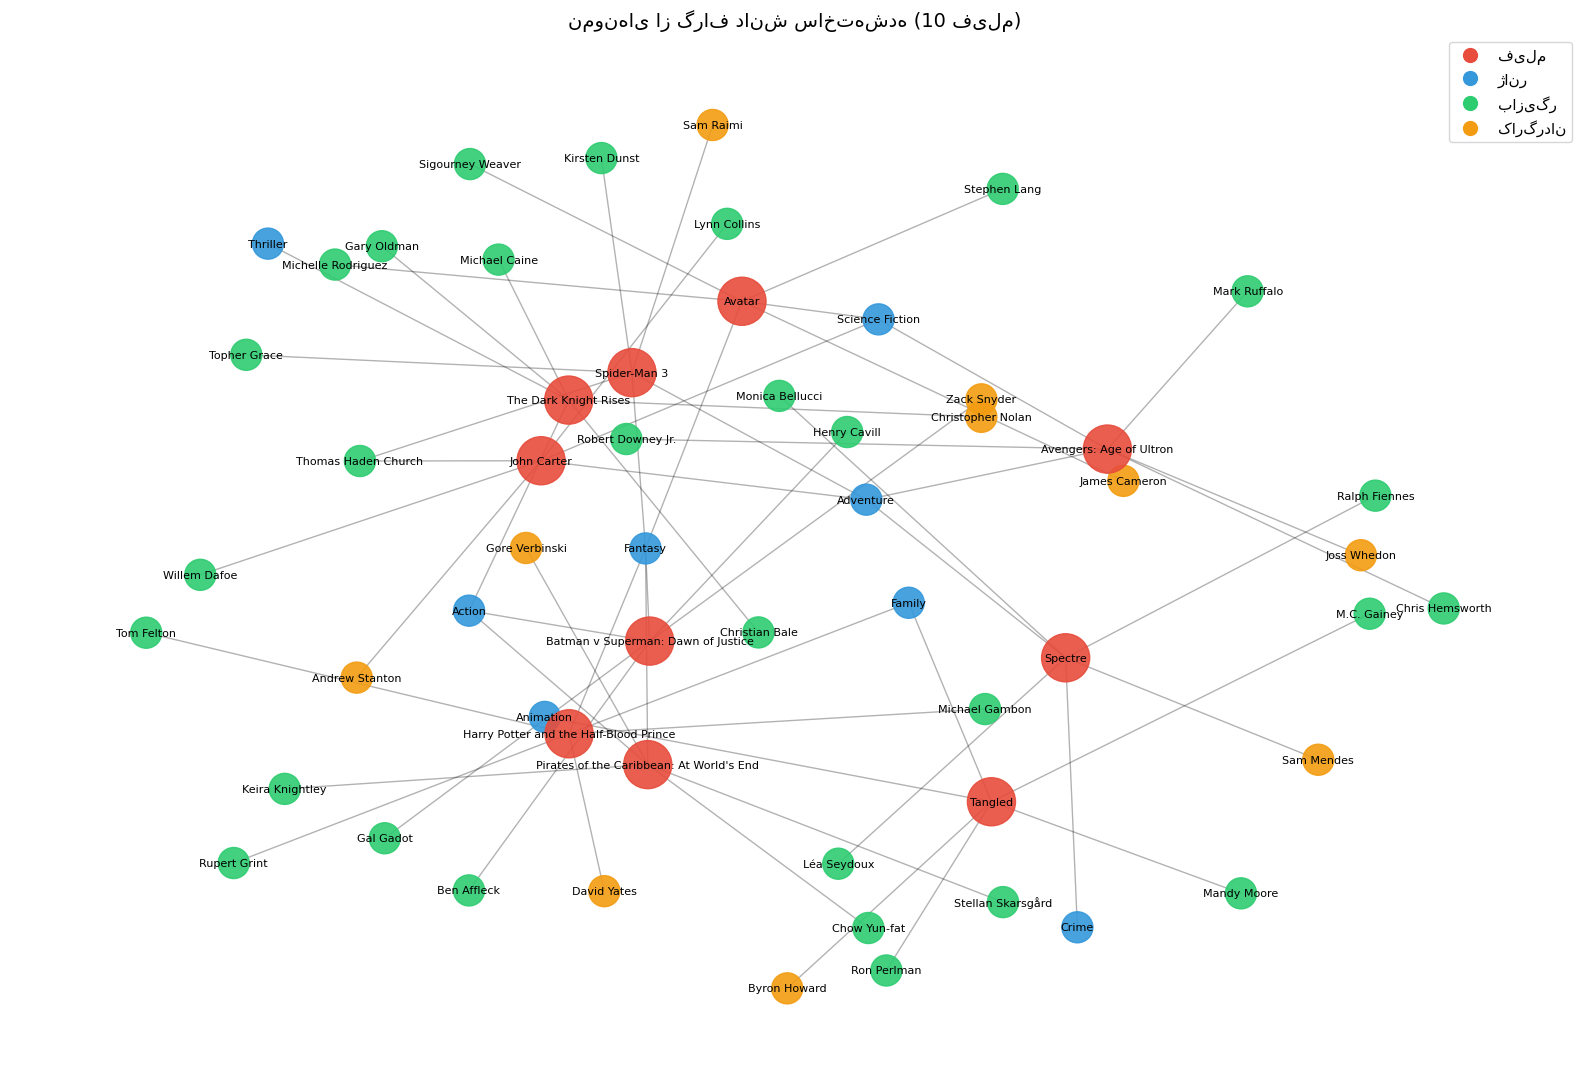

✅ تصویر گراف نمایش داده و در graph_sample.png ذخیره شد.


In [14]:
import networkx as nx
import matplotlib.pyplot as plt

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD_COLAB))
with driver.session() as session:
    result = session.run("""
        MATCH (m:Movie)
        OPTIONAL MATCH (m)-[:HAS_GENRE]->(g:Genre)
        OPTIONAL MATCH (a:Actor)-[:ActED_IN]->(m)
        OPTIONAL MATCH (d:Director)-[:DIRECTED]->(m)
        WITH m, collect(DISTINCT g.name)[0..2] AS genres,
                collect(DISTINCT a.name)[0..3] AS actors,
                d.name AS director
        WHERE size(genres) > 0 AND size(actors) > 0
        RETURN m.title AS title, genres, actors, director
        LIMIT 10
    """)
    sample = [record.data() for record in result]
driver.close()

print(f"✅ {len(sample)} فیلم نمونه برای نمایش گراف پیدا شد.")

G = nx.Graph()
node_colors = []
node_labels = {}

for row in sample:
    movie = row["title"]
    G.add_node(movie, kind="movie")
    for g in row["genres"]:
        if g:
            G.add_node(g, kind="genre")
            G.add_edge(movie, g)
    for a in row["actors"]:
        if a:
            G.add_node(a, kind="actor")
            G.add_edge(movie, a)
    if row["director"] and row["director"] != "none":
        G.add_node(row["director"], kind="director")
        G.add_edge(movie, row["director"])

color_map = {"movie": "#e74c3c", "genre": "#3498db", "actor": "#2ecc71", "director": "#f39c12"}
colors = [color_map[G.nodes[n]["kind"]] for n in G.nodes]
sizes = [1200 if G.nodes[n]["kind"] == "movie" else 500 for n in G.nodes]

plt.figure(figsize=(16, 11))
pos = nx.spring_layout(G, k=0.6, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, font_size=8, font_family="DejaVu Sans")

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=lbl, markerfacecolor=c, markersize=12)
    for lbl, c in [("فیلم", "#e74c3c"), ("ژانر", "#3498db"), ("بازیگر", "#2ecc71"), ("کارگردان", "#f39c12")]
]
plt.legend(handles=legend_elements, loc="upper right", fontsize=11)
plt.title(f"نمونه‌ای از گراف دانش ساخته‌شده ({len(sample)} فیلم)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("graph_sample.png", dpi=120, bbox_inches="tight")
plt.show()

print("✅ تصویر گراف نمایش داده و در graph_sample.png ذخیره شد.")


## بخش ۷: نوشتن اسکریپت GraphRAG (لایهٔ API به‌جای CLI تعاملی)

نسخه‌ی به‌روزشده با این تغییرات:
1. **`bitsandbytes` به‌روزرسانی شد (`>=0.43.1`)** — نسخهٔ قبلی (۰.۴۲.۰) روی ایمیج فعلی Colab با خطای «CUDA Setup failed despite GPU being available» کرش می‌کرد (باگ شناخته‌شدهٔ ماژول تشخیص CUDA در نسخه‌های قدیمی‌تر از ۰.۴۳)؛ `accelerate` هم به نسخهٔ هم‌دورانِ آن (`0.30.1`) به‌روز شد.
2. **بارگذاری مدل همچنان با `AutoModel` است، نه `AutoModelForCausalLM`.** طبق بررسی مستقیم مخزن رسمی LLaDA (کد `generate.py`، کارت مدل HF، و کارت LLaDA-1.5)، همه از `AutoModel` استفاده می‌کنند.
3. **`EntityExtractor` بازنویسی کامل شد:** کل پرامپت یک‌بار از پایپ‌لاین کامل spaCy عبور می‌کند و خروجی تمیزشده، پایهٔ تمام تطبیق‌ها می‌شود.
4. **🆕 لایهٔ CLI تعاملی (`input()`/`print()`) با یک سرور HTTP سبک مبتنی بر Flask جایگزین شد.** منطق پردازش هر پرامپت (استخراج موجودیت → کوئری گراف محلی → در صورت خالی‌بودن جستجوی وب → تولید پاسخ با مدل دیفیوژن) بدون **هیچ تغییری** عیناً همان کد قبلی است؛ فقط به‌جای خواندن از `input()` و چاپ در ترمینال Colab، حالا یک endpoint به آدرس `POST /chat` این کار را انجام می‌دهد. این یعنی پرامپت را دیگر داخل خود Colab تایپ نمی‌کنید — آن را از صفحهٔ چت HTML که در مرورگر خودتان باز می‌کنید ارسال می‌کنید، و پاسخ هم همان‌جا نمایش داده می‌شود (به بخش ۸ و ۹ نگاه کنید).

**🆕 اصلاحات بعدی:**
5. مدل دیفیوژن دیگر lazy لود نمی‌شود؛ همان لحظه‌ای که سرور راه می‌افتد (قبل از پذیرفتن هر درخواستی) لود می‌شود — قبلاً اولین سوال کاربر مجبور بود منتظر لود چند-دقیقه‌ای مدل بماند و اغلب با خطا مواجه می‌شد.
6. الگوی پرامپت دیگر همیشه فارسی نیست: بر اساس زبان سوال کاربر (فارسی/انگلیسی تشخیص داده می‌شود)، الگوی متناسب انتخاب می‌شود تا پاسخ به همان زبانی باشد که سوال پرسیده شده.
7. یک مرحلهٔ پاک‌سازی (`_clean_answer`) اضافه شد که اگر مدل دیفیوژن به‌جای پاسخ نهایی، بخشی از دستورالعمل یا عین متن زمینه (context) را در خروجی تکرار کند، آن را حذف می‌کند تا کاربر فقط پاسخ واقعی را ببیند.

In [15]:
%%writefile graphrag_movie_cli.py
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
GraphRAG Movie Assistant — Interactive Terminal CLI
=====================================================

Architecture:
  1) Orchestrator      -> extracts entities (genre / actor / director / year) from the
                           free-text prompt using Regex + dictionary/fuzzy matching
                           (NOT the diffusion model — diffusion LLMs are bad at emitting
                           structured Cypher, so structured parsing is done in code).
  2) Neo4j layer        -> builds a Cypher query from the extracted entities and runs it
                           against the local knowledge graph.
  3) Routing layer       -> if the local graph returns nothing, falls back to a web
                           search (DuckDuckGo by default, Tavily if you set an API key).
  4) Diffusion LLM layer -> the retrieved context (local or web) is stuffed into a
                           prompt template and handed to a diffusion language model
                           (e.g. LLaDA-8B) loaded via `transformers` to produce the
                           final natural-language answer.
  5) CLI layer           -> a REPL loop ("User: ") that keeps running until the user
                           types exit/quit, then closes the Neo4j driver safely.

Graph schema this script assumes:
  (:Movie {title})
  (:Movie)-[:IN_YEAR]->(:Year {year})
  (:Movie)-[:WITH_POINTS {real_rating}]->(:RATING {rating})
  (:Movie)-[:HAS_GENRE]->(:Genre {name})
  (:Actor)-[:ActED_IN]->(:Movie)
  (:Director)-[:DIRECTED]->(:Movie)
"""

import re
import sys
import traceback
from typing import Dict, List, Optional, Any

from neo4j import GraphDatabase

# --------------------------------------------------------------------------------------
# 0. CONFIGURATION — these placeholders are filled in automatically by the notebook cell
#    that writes this file.
# --------------------------------------------------------------------------------------

NEO4J_URI = "bolt://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "__NEO4J_PASSWORD__"

# Whether to attempt loading the diffusion LLM at all. Set to False (via the
# notebook config cell) to always use the fast template fallback without loading
# any model.
DIFFUSION_ENABLED = __DIFFUSION_ENABLED__

# STRICT mode: if True, a failure to load/run the diffusion model raises an
# explicit exception instead of silently degrading to the template fallback. Useful
# while actively debugging the diffusion layer, since it forces the real error to
# surface immediately instead of being swallowed. Set to False for a live demo /
# final submission run, so a transient failure doesn't kill the whole CLI session.
STRICT_DIFFUSION_MODE = __STRICT_DIFFUSION_MODE__

# Optional: set a Tavily API key in the notebook config cell to use Tavily instead of
# the free DuckDuckGo search fallback.
TAVILY_API_KEY: Optional[str] = None

MAX_RESULTS = 8


# --------------------------------------------------------------------------------------
# 1. ORCHESTRATOR — entity extraction (Regex + dictionary/fuzzy matching, no LLM)
# --------------------------------------------------------------------------------------

class EntityExtractor:
    YEAR_PATTERN = re.compile(r"\b(19\d{2}|20\d{2})\b")

    # The knowledge graph stores genres in English (raw TMDB values, e.g. "Action"),
    # but prompts are frequently Persian. Fuzzy/substring matching Persian text
    # against English genre names can never work (different scripts), so genres are
    # matched via this explicit keyword dictionary FIRST, before falling back to the
    # generic Latin matcher for English-language prompts.
    PERSIAN_GENRE_MAP = {
        "اکشن": "Action",
        "ماجراجویی": "Adventure",
        "انیمیشن": "Animation",
        "کمدی": "Comedy",
        "جنایی": "Crime",
        "مستند": "Documentary",
        "درام": "Drama",
        "خانوادگی": "Family",
        "فانتزی": "Fantasy",
        "تخیلی": "Fantasy",
        "تاریخی": "History",
        "ترسناک": "Horror",
        "وحشت": "Horror",
        "موزیکال": "Music",
        "موسیقی": "Music",
        "معمایی": "Mystery",
        "رازآلود": "Mystery",
        "عاشقانه": "Romance",
        "رمانتیک": "Romance",
        "علمی تخیلی": "Science Fiction",
        "علمی‌تخیلی": "Science Fiction",
        "علمی-تخیلی": "Science Fiction",
        "تلویزیونی": "TV Movie",
        "هیجان انگیز": "Thriller",
        "هیجان‌انگیز": "Thriller",
        "تریلر": "Thriller",
        "جنگی": "War",
        "وسترن": "Western",
    }

    # Cue words that tell us whether a matched name should be treated as the ACTOR
    # or the DIRECTOR. This matters because some people (e.g. Tom Hanks) are BOTH an
    # Actor node and a Director node in the graph — without this disambiguation, a
    # prompt like "فیلمی با بازی Tom Hanks" would match him as actor AND director
    # simultaneously, and the Cypher query would then require a movie where he is
    # both at once (almost never true), silently returning zero results even though
    # he is clearly present in the graph.
    ACTOR_CUES = ["بازی", "بازیگر", "نقش", "با حضور", "starring", "actor", "played by", "with"]
    DIRECTOR_CUES = ["کارگردان", "کارگردانی", "ساخته", "directed by", "director", "made by"]

    def __init__(self, known_genres: List[str], known_actors: List[str],
                 known_directors: List[str]):
        self.known_genres = known_genres
        self.known_actors = known_actors
        self.known_directors = known_directors

        try:
            from rapidfuzz import process, fuzz
            self._process = process
            self._fuzz = fuzz
            self._fuzzy_available = True
        except ImportError:
            self._fuzzy_available = False
            print("[warn] rapidfuzz not installed — falling back to plain substring "
                  "matching for names/genres.")

        # spaCy is used as a lightweight, accurate NLP preprocessor: its NER model
        # tags PERSON spans directly (e.g. it recognizes "Tom Hanks" as one entity),
        # which is a more reliable candidate source for actor/director matching than
        # blindly sliding a word-window over the raw prompt. It only understands
        # English, so it's used as an extra signal alongside (not instead of) the
        # existing n-gram/fuzzy matcher, which still covers Persian-adjacent text.
        try:
            import spacy
            self._nlp = spacy.load("en_core_web_sm")
        except (ImportError, OSError):
            self._nlp = None
            print("[warn] spaCy/en_core_web_sm not available — name extraction will "
                  "rely only on the n-gram/fuzzy matcher (still functional).")

    def _spacy_preprocess(self, prompt: str) -> (List[str], List[str]):
        """Runs the full spaCy pipeline ONCE per prompt — tokenization, lemmatization,
        and stripping of punctuation/stopwords — BEFORE any matching against the
        graph's vocabulary takes place, as requested. Returns:
          - cleaned_tokens: lemmatized tokens with punctuation and English stopwords
            removed, used to build n-gram candidates for actor/director/genre
            matching (replaces the old naive prompt.split()).
          - person_entities: spaCy's PERSON-tagged spans (e.g. "Tom Hanks" as one
            unit) — a higher-precision candidate source than sliding n-grams.

        Note on Persian: en_core_web_sm has no Persian model, so Persian tokens
        simply pass through cleaned_tokens inertly (not flagged as stopwords, lemma
        unchanged) rather than being mishandled. For that reason, the Persian
        genre-keyword dictionary and the actor/director role-cue detection
        deliberately still scan the ORIGINAL raw prompt, not this English-oriented
        spaCy output — running Persian text through an English stopword/lemma filter
        would risk corrupting it for no benefit, since spaCy can't meaningfully
        lemmatize or POS-tag Persian anyway.
        """
        if self._nlp is None:
            return prompt.split(), []
        doc = self._nlp(prompt)
        cleaned_tokens = [
            tok.lemma_ for tok in doc
            if not tok.is_punct and not tok.is_space and not tok.is_stop
        ]
        person_entities = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
        return cleaned_tokens, person_entities

    def _exact_substring_match(self, prompt: str, choices: List[str]) -> Optional[str]:
        """Deterministic pass: does a known name literally appear in the prompt
        (case-insensitive)? Checked BEFORE fuzzy matching, zero false-positive risk.
        Length >= 4 avoids a short word matching almost anything."""
        prompt_lower = prompt.lower()
        best = None
        for choice in choices:
            if len(choice) >= 4 and choice.lower() in prompt_lower:
                if best is None or len(choice) > len(best):
                    best = choice
        return best

    def _best_fuzzy_match(self, text: str, choices: List[str], score_cutoff: int = 90
                           ) -> Optional[str]:
        if not choices:
            return None
        if self._fuzzy_available:
            # fuzz.ratio (whole-string Levenshtein similarity) is used instead of
            # fuzz.WRatio. WRatio blends in partial_ratio, which scores a short
            # chunk as a near-perfect match whenever it happens to be a substring
            # of a much longer candidate (e.g. "tom" scores ~100 against "Satomi
            # Ishihara" because "tom" is literally inside "Sa-TOM-i"). That caused
            # real false positives (e.g. "tom hanks" wrongly resolving to an
            # unrelated actor/director). fuzz.ratio does not do partial/substring
            # scoring, so short chunks no longer spuriously match unrelated names.
            match = self._process.extractOne(
                text, choices, scorer=self._fuzz.ratio, score_cutoff=score_cutoff
            )
            return match[0] if match else None
        text_lower = text.lower()
        for choice in choices:
            if choice.lower() in text_lower:
                return choice
        return None

    def _find_in_ngrams(self, cleaned_tokens: List[str], choices: List[str]) -> Optional[str]:
        """Matches against the spaCy-cleaned token stream (lemmatized, no
        punctuation/stopwords) instead of a naive prompt.split()."""
        # Pass 1: exact (case-insensitive) substring match over the cleaned tokens.
        exact = self._exact_substring_match(" ".join(cleaned_tokens), choices)
        if exact:
            return exact

        # Pass 2: fuzzy match, for typos / slightly different spelling only.
        for n in (4, 3, 2, 1):
            for i in range(len(cleaned_tokens) - n + 1):
                chunk = " ".join(cleaned_tokens[i:i + n])
                if len(chunk) < 4:
                    continue
                match = self._best_fuzzy_match(chunk, choices, score_cutoff=90)
                if match:
                    return match
        return None

    def _match_name(self, person_entities: List[str], cleaned_tokens: List[str],
                     choices: List[str]) -> Optional[str]:
        """Name matching for actor/director: tries spaCy's PERSON entities first
        (precise, whole-name spans), then falls back to the cleaned-token n-gram/
        fuzzy matcher (covers cases spaCy's NER misses, and non-English text)."""
        for candidate in person_entities:
            match = (self._exact_substring_match(candidate, choices)
                     or self._best_fuzzy_match(candidate, choices, score_cutoff=88))
            if match:
                return match
        return self._find_in_ngrams(cleaned_tokens, choices)

    def _match_genre(self, prompt: str, cleaned_tokens: List[str]) -> Optional[str]:
        normalized = prompt.replace("\u200c", " ")  # strip Persian ZWNJ (نیم‌فاصله)
        for fa_term, en_genre in self.PERSIAN_GENRE_MAP.items():
            if fa_term in normalized and en_genre in self.known_genres:
                return en_genre
        # English-language prompt fallback: match against the cleaned token stream.
        return self._find_in_ngrams(cleaned_tokens, self.known_genres)

    def _match_actor_and_director(self, prompt: str, cleaned_tokens: List[str],
                                   person_entities: List[str]) -> (Optional[str], Optional[str]):
        prompt_lower = prompt.lower()
        has_actor_cue = any(cue in prompt_lower for cue in self.ACTOR_CUES)
        has_director_cue = any(cue in prompt_lower for cue in self.DIRECTOR_CUES)

        if has_director_cue and not has_actor_cue:
            return None, self._match_name(person_entities, cleaned_tokens, self.known_directors)
        if has_actor_cue and not has_director_cue:
            return self._match_name(person_entities, cleaned_tokens, self.known_actors), None

        # No cue, or both cues present: check both lists independently.
        actor = self._match_name(person_entities, cleaned_tokens, self.known_actors)
        director = self._match_name(person_entities, cleaned_tokens, self.known_directors)
        if actor and director and actor == director and not has_director_cue:
            # Same person matched in both roles with no explicit director cue —
            # default to actor-only so the query isn't over-constrained.
            director = None
        return actor, director

    def extract(self, prompt: str) -> Dict[str, Any]:
        entities: Dict[str, Any] = {"year": None, "genre": None, "actor": None, "director": None}
        year_match = self.YEAR_PATTERN.search(prompt)
        if year_match:
            entities["year"] = int(year_match.group(1))

        # Single spaCy pass per prompt (tokenize + lemmatize + strip punctuation/
        # stopwords), BEFORE any matching against the graph vocabulary — its output
        # feeds every matcher below instead of each one re-splitting the raw string.
        cleaned_tokens, person_entities = self._spacy_preprocess(prompt)

        entities["genre"] = self._match_genre(prompt, cleaned_tokens)
        entities["actor"], entities["director"] = self._match_actor_and_director(
            prompt, cleaned_tokens, person_entities
        )
        return entities


# --------------------------------------------------------------------------------------
# 2 & 3. NEO4J LAYER + ROUTING
# --------------------------------------------------------------------------------------

class MovieGraphRAG:
    def __init__(self, uri: str, user: str, password: str):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))
        self._verify_connection()

    def _verify_connection(self):
        with self.driver.session() as session:
            session.run("RETURN 1").consume()

    def close(self):
        self.driver.close()

    def fetch_vocabulary(self) -> Dict[str, List[str]]:
        with self.driver.session() as session:
            genres = session.run("MATCH (g:Genre) RETURN g.name AS name").value("name")
            actors = session.run("MATCH (a:Actor) RETURN a.name AS name").value("name")
            directors = session.run("MATCH (d:Director) RETURN d.name AS name").value("name")
        return {
            "genres": [g for g in genres if g],
            "actors": [a for a in actors if a],
            "directors": [d for d in directors if d],
        }

    @staticmethod
    def build_cypher(entities: Dict[str, Any]) -> (str, Dict[str, Any]):
        match_clauses = ["MATCH (m:Movie)"]
        where_clauses = []
        params: Dict[str, Any] = {}

        if entities.get("genre"):
            match_clauses.append("MATCH (m)-[:HAS_GENRE]->(g:Genre)")
            where_clauses.append("toLower(g.name) = toLower($genre)")
            params["genre"] = entities["genre"]

        if entities.get("actor"):
            match_clauses.append("MATCH (a:Actor)-[:ActED_IN]->(m)")
            where_clauses.append("toLower(a.name) = toLower($actor)")
            params["actor"] = entities["actor"]

        if entities.get("director"):
            match_clauses.append("MATCH (d:Director)-[:DIRECTED]->(m)")
            where_clauses.append("toLower(d.name) = toLower($director)")
            params["director"] = entities["director"]

        if entities.get("year"):
            match_clauses.append("MATCH (m)-[:IN_YEAR]->(y:Year)")
            where_clauses.append("y.year = $year")
            params["year"] = entities["year"]

        query = "\n".join(match_clauses)
        if where_clauses:
            query += "\nWHERE " + " AND ".join(where_clauses)

        query += """
OPTIONAL MATCH (m)-[:HAS_GENRE]->(all_g:Genre)
OPTIONAL MATCH (all_a:Actor)-[:ActED_IN]->(m)
OPTIONAL MATCH (all_d:Director)-[:DIRECTED]->(m)
OPTIONAL MATCH (m)-[:IN_YEAR]->(all_y:Year)
OPTIONAL MATCH (m)-[wp:WITH_POINTS]->(:RATING)
RETURN DISTINCT
    m.title AS title,
    all_y.year AS year,
    wp.real_rating AS rating,
    collect(DISTINCT all_g.name) AS genres,
    collect(DISTINCT all_a.name) AS actors,
    all_d.name AS director
LIMIT $limit
"""
        params["limit"] = MAX_RESULTS
        return query, params

    def query_local_graph(self, entities: Dict[str, Any]) -> List[Dict[str, Any]]:
        query, params = self.build_cypher(entities)
        with self.driver.session() as session:
            result = session.run(query, params)
            return [record.data() for record in result]


class WebSearchFallback:
    def __init__(self, tavily_api_key: Optional[str] = None):
        self.tavily_api_key = tavily_api_key

    def search(self, query: str) -> List[Dict[str, str]]:
        if self.tavily_api_key:
            return self._search_tavily(query)
        return self._search_duckduckgo(query)

    def _search_tavily(self, query: str) -> List[Dict[str, str]]:
        try:
            from tavily import TavilyClient
        except ImportError:
            print("[warn] tavily-python not installed. Falling back to DuckDuckGo.")
            return self._search_duckduckgo(query)
        client = TavilyClient(api_key=self.tavily_api_key)
        response = client.search(query=query, max_results=5)
        return [{"title": r.get("title", ""), "snippet": r.get("content", "")}
                for r in response.get("results", [])]

    def _search_duckduckgo(self, query: str) -> List[Dict[str, str]]:
        try:
            from ddgs import DDGS
        except ImportError:
            try:
                from duckduckgo_search import DDGS
            except ImportError:
                print("[warn] no web search library installed (`pip install ddgs`).")
                return []
        results = []
        with DDGS() as ddgs:
            for r in ddgs.text(query, max_results=5):
                results.append({"title": r.get("title", ""), "snippet": r.get("body", "")})
        return results


# --------------------------------------------------------------------------------------
# 4. DIFFUSION LLM LAYER
# --------------------------------------------------------------------------------------

class DiffusionResponder:
    """
    Loads GSAI-ML/LLaDA-8B-Instruct, currently the best-documented free, open-weight
    diffusion LLM, and produces the final answer using it.

    This implementation was rewritten after checking the model's OFFICIAL repository
    (github.com/ML-GSAI/LLaDA) directly, because three earlier assumptions turned out
    to be wrong and were the real cause of repeated crashes:

      1. The official docs pin `transformers==4.38.2` — a much older version than
         what generic `pip install --upgrade transformers` installs. That huge
         version gap against the checkpoint's custom `trust_remote_code` is what was
         producing import errors deep inside `transformers`.
      2. The official loading example uses `AutoModel`, never `AutoModelForCausalLM`.
      3. LLaDA does NOT implement a standard `model.generate()`. It's a masked
         diffusion model — the official repo ships its own sampling loop
         (`generate.py`) that repeatedly calls the model's raw forward pass and
         iteratively "unmasks" tokens. There is no drop-in `.generate()` to call.

    `_diffusion_generate()` below reproduces that official sampling loop directly
    (mask-and-denoise with low-confidence remasking), so it calls the model in
    exactly the way its authors intended, instead of guessing at a HF-style API that
    this architecture never actually provides.

    Note: Dream-7B was considered as a second option but its own README explicitly
    states it "requires a GPU with at least 20GB memory" — more than the free Colab
    T4's 15GB — so it isn't a realistic free-tier choice and was dropped.
    """

    MODEL_NAME = "GSAI-ML/LLaDA-8B-Instruct"
    MASK_ID = 126336  # LLaDA's official [MASK] token id (documented in its model card)

    # قبلاً فقط یک الگوی فارسی وجود داشت که همیشه استفاده می‌شد، حتی اگر خود
    # کاربر انگلیسی سوال می‌پرسید — و مدل هم گاهی به‌جای پاسخ نهایی، عین متن
    # دستورالعمل/کانتکس بالای پرامپت را در خروجی تکرار می‌کرد. حالا: (۱) بر اساس
    # زبان سوال کاربر، الگوی فارسی یا انگلیسی انتخاب می‌شود و صریحاً از مدل
    # خواسته می‌شود به همان زبان و فقط با متن پاسخ نهایی جواب بدهد، (۲) یک نشانگر
    # مشخص («پاسخ نهایی:» / «Final answer:») انتهای پرامپت اضافه شده تا در صورت
    # نشت بخشی از پرامپت به خروجی مدل (رفتار شناخته‌شدهٔ مدل‌های دیفیوژن ضعیف در
    # پیروی از دستور)، بتوان آن را در _clean_answer به‌طور قابل‌اعتماد پیدا و حذف کرد.
    PERSIAN_CHAR_RE = re.compile(r"[\u0600-\u06FF]")

    PROMPT_TEMPLATE_FA = (
        "زمینهٔ (context) زیر را فقط برای پیدا کردن اطلاعات لازم بخوان؛ آن را و این "
        "دستورالعمل را عیناً در پاسخ کپی نکن.\n\n"
        "زمینه:\n{context}\n\n"
        "سوال کاربر: {user_prompt}\n\n"
        "با توجه به زمینهٔ بالا، یک پاسخ نهایی کوتاه، دوستانه و پیشنهادی فقط به "
        "زبان فارسی بنویس (نه دستورالعمل بالا، نه متن زمینه را تکرار نکن):\n"
        "پاسخ نهایی:"
    )

    PROMPT_TEMPLATE_EN = (
        "Read the context below only to find the information you need; do not copy "
        "it or these instructions verbatim into your reply.\n\n"
        "Context:\n{context}\n\n"
        "User question: {user_prompt}\n\n"
        "Based on the context above, write a short, friendly, suggestive final "
        "answer in English only (do not repeat the instructions above or the "
        "context text):\n"
        "Final answer:"
    )

    ANSWER_MARKERS = ["پاسخ نهایی:", "Final answer:"]

    def __init__(self, enabled: bool, strict: bool = False):
        self.enabled = enabled
        self.strict = strict
        self.tokenizer = None
        self.model = None
        self.loaded_model_name: Optional[str] = None
        self._load_attempted = False

    def _lazy_load(self):
        if self._load_attempted or not self.enabled:
            return
        self._load_attempted = True

        import torch
        if not torch.cuda.is_available():
            msg = ("GPU در دسترس نیست؛ مدل دیفیوژن ۸ میلیاردی روی CPU لود نمی‌شود "
                   "(نیاز به حافظه‌ای غیرعملی دارد). برای فعال‌سازی، در Colab از "
                   "Runtime > Change runtime type > GPU استفاده کنید.")
            if self.strict:
                raise RuntimeError(msg)
            print(f"[warn] {msg} از پاسخ الگو-محور استفاده می‌شود.")
            return

        # Proactive RAM check: loading an 8B checkpoint briefly needs several GB of
        # *system* RAM while shards are read/converted (more so with
        # low_cpu_mem_usage=False, used below as a fallback path — see note there).
        # On free-tier Colab (~12GB RAM) insufficient headroom can silently OOM-kill
        # the kernel — bypassing try/except entirely (the process is killed, not a
        # catchable Python exception). Skipping the attempt avoids crashing outright.
        try:
            import psutil
            available_gb = psutil.virtual_memory().available / (1024 ** 3)
            if available_gb < 9:
                msg = (f"فقط ~{available_gb:.1f} گیگابایت RAM آزاد است — ریسک کرش "
                       f"کرنل در صورت تلاش برای لود مدل. Runtime > Restart session "
                       f"بزنید و این سلول را زودتر (با RAM آزادتر) اجرا کنید.")
                if self.strict:
                    raise RuntimeError(msg)
                print(f"[warn] {msg} از پاسخ الگو-محور استفاده می‌شود.")
                return
        except ImportError:
            pass

        from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

        print(f"[info] در حال لود مدل دیفیوژن '{self.MODEL_NAME}' (4-bit، ممکن "
              f"است چند دقیقه طول بکشد، لطفاً تب Colab را باز نگه دارید)...")
        # bnb_4bit_compute_dtype=float16 (not bfloat16): the free-tier T4 is a
        # Turing-generation GPU without native bf16 tensor-core support, so fp16 is
        # the hardware-appropriate compute dtype here.
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.MODEL_NAME, trust_remote_code=True)

        # Two-attempt loading strategy. Attempt 1 uses low_cpu_mem_usage=True (the
        # default transformers applies automatically for quantized models) — this is
        # RAM-lean but, with LLaDA's custom trust_remote_code class specifically, can
        # trigger `ValueError: .to is not supported for 4-bit or 8-bit bitsandbytes
        # models` from inside from_pretrained's own meta-tensor dispatch step (a bug
        # in how this particular custom model class interacts with that codepath —
        # not something fixable via from_pretrained kwargs alone). If that exact
        # error occurs, attempt 2 retries with low_cpu_mem_usage=False, which avoids
        # meta-tensor loading entirely (the model materializes normally on CPU first,
        # then bitsandbytes quantizes it onto the GPU) — more system RAM, but sidesteps
        # the buggy codepath.
        last_error = None
        for attempt, low_cpu_mem_usage in enumerate([True, False], start=1):
            try:
                self.model = AutoModel.from_pretrained(
                    self.MODEL_NAME,
                    trust_remote_code=True,
                    quantization_config=bnb_config,
                    low_cpu_mem_usage=low_cpu_mem_usage,
                )
                self.model.eval()
                self.loaded_model_name = self.MODEL_NAME
                print(f"[info] ✅ مدل دیفیوژن '{self.MODEL_NAME}' با موفقیت لود شد "
                      f"(تلاش {attempt}, low_cpu_mem_usage={low_cpu_mem_usage}).")
                return
            except ValueError as e:
                if "not supported for" in str(e) and attempt == 1:
                    print(f"[warn] تلاش {attempt} (low_cpu_mem_usage=True) با خطای "
                          f"شناخته‌شدهٔ سازگاری برخورد کرد — تلاش دوباره با "
                          f"low_cpu_mem_usage=False...")
                    last_error = e
                    continue
                last_error = e
                break
            except Exception as e:
                last_error = e
                break

        # Both attempts failed.
        self.model = None
        self.tokenizer = None
        if self.strict:
            raise RuntimeError(f"لود مدل دیفیوژن پس از هر دو تلاش شکست خورد: {last_error}") from last_error
        print("[warn] لود مدل دیفیوژن ناموفق بود — از پاسخ الگو-محور استفاده می‌شود.")
        traceback.print_exc(limit=1)

    @staticmethod
    def _add_gumbel_noise(logits, temperature):
        import torch
        if temperature == 0:
            return logits
        logits = logits.to(torch.float64)
        noise = torch.rand_like(logits, dtype=torch.float64)
        gumbel_noise = (-torch.log(noise)) ** temperature
        return logits.exp() / gumbel_noise

    @staticmethod
    def _get_num_transfer_tokens(mask_index, steps):
        import torch
        mask_num = mask_index.sum(dim=1, keepdim=True)
        base = mask_num // steps
        remainder = mask_num % steps
        num_transfer_tokens = (
            torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
        )
        for i in range(mask_num.size(0)):
            num_transfer_tokens[i, :remainder[i]] += 1
        return num_transfer_tokens

    def _diffusion_generate(self, prompt_ids, gen_length=96, block_length=32,
                             steps=48, temperature=0.7, remasking="low_confidence"):
        """Reproduces LLaDA's official masked-diffusion sampling loop (generate.py in
        github.com/ML-GSAI/LLaDA): starts from an all-[MASK] canvas after the prompt
        and iteratively fills in the most confident tokens block-by-block, rather
        than generating left-to-right like an autoregressive model."""
        import torch
        import torch.nn.functional as F

        device = self.model.device
        x = torch.full((1, prompt_ids.shape[1] + gen_length), self.MASK_ID,
                        dtype=torch.long, device=device)
        x[:, :prompt_ids.shape[1]] = prompt_ids.to(device)
        prompt_len = prompt_ids.shape[1]

        assert gen_length % block_length == 0
        num_blocks = gen_length // block_length
        assert steps % num_blocks == 0
        steps_per_block = steps // num_blocks

        # رفع باگ حافظه: نسخهٔ قبلی کل حلقهٔ نمونه‌گیری را بدون torch.no_grad() اجرا
        # می‌کرد، یعنی PyTorch برای هر یک از این فوروارد پس‌های تکراری (تا ۴۸ بار،
        # هرکدام روی کل دنباله) گراف اتوگرید و activationها را نگه می‌داشت — دقیقاً
        # طراحی‌شده برای backward pass که این‌جا اصلاً استفاده نمی‌شود. روی T4 با
        # ~15GB VRAM همین یک مورد به‌تنهایی می‌توانست باعث OOM شود. inference_mode
        # این سربار را کاملاً حذف می‌کند بدون این‌که منطق نمونه‌گیری تغییر کند.
        with torch.inference_mode():
            for b in range(num_blocks):
                block_start = prompt_len + b * block_length
                block_end = prompt_len + (b + 1) * block_length
                block_mask_index = (x[:, block_start:block_end] == self.MASK_ID)
                num_transfer_tokens = self._get_num_transfer_tokens(block_mask_index, steps_per_block)

                for i in range(steps_per_block):
                    mask_index = (x == self.MASK_ID)
                    logits = self.model(x).logits
                    logits_with_noise = self._add_gumbel_noise(logits, temperature=temperature)
                    x0 = torch.argmax(logits_with_noise, dim=-1)

                    if remasking == "low_confidence":
                        p = F.softmax(logits.to(torch.float64), dim=-1)
                        x0_p = torch.squeeze(torch.gather(p, dim=-1, index=torch.unsqueeze(x0, -1)), -1)
                    else:
                        x0_p = torch.rand(x0.shape, device=device)

                    x0_p[:, block_end:] = -float("inf")
                    x0 = torch.where(mask_index, x0, x)
                    confidence = torch.where(mask_index, x0_p, torch.tensor(-float("inf"), device=device))

                    transfer_index = torch.zeros_like(x0, dtype=torch.bool)
                    k = int(num_transfer_tokens[0, i].item())
                    if k > 0:
                        _, select_index = torch.topk(confidence[0], k=k)
                        transfer_index[0, select_index] = True
                    x[transfer_index] = x0[transfer_index]

                # رفع باگ حافظه: بین بلوک‌ها کش تخصیص‌دهندهٔ CUDA را خالی می‌کنیم تا
                # قطعات آزادشدهٔ حافظه (logits موقت هر مرحله) واقعاً به سیستم برگردند
                # و در طول یک نشست طولانی REPL VRAM به‌تدریج پر نشود.
                if device.type == "cuda":
                    torch.cuda.empty_cache()

        return x[:, prompt_len:]

    def _run_model(self, final_prompt: str) -> str:
        messages = [{"role": "user", "content": final_prompt}]
        prompt_ids = self.tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, return_tensors="pt"
        )
        output_ids = self._diffusion_generate(prompt_ids)
        text = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        # رفع باگ حافظه: بعد از هر پاسخ کامل، کش VRAM را یک‌بار دیگر خالی می‌کنیم —
        # مهم برای حلقهٔ REPL که ممکن است ده‌ها پرامپت پشت سر هم در یک نشست Colab
        # پردازش شوند.
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return text.strip()

    def respond(self, user_prompt: str, context: str) -> (str, Optional[str]):
        """Returns (answer_text, model_name_used_or_None). model_name_used is None
        when the template fallback was used instead of the diffusion model."""
        is_persian = bool(self.PERSIAN_CHAR_RE.search(user_prompt))
        template = self.PROMPT_TEMPLATE_FA if is_persian else self.PROMPT_TEMPLATE_EN
        final_prompt = template.format(context=context, user_prompt=user_prompt)
        self._lazy_load()
        if self.model is not None and self.tokenizer is not None:
            try:
                raw = self._run_model(final_prompt)
                answer = self._clean_answer(raw, context)
                return answer, self.loaded_model_name
            except Exception:
                if self.strict:
                    raise
                print("[warn] diffusion model inference failed — using template fallback.")
                traceback.print_exc(limit=1)
        elif self.strict:
            raise RuntimeError("مدل دیفیوژن لود نشده و STRICT_DIFFUSION_MODE فعال است — "
                                "طبق تنظیمات، اجازهٔ استفاده از پاسخ الگو-محور وجود ندارد.")
        return self._fallback_response(context, is_persian), None

    @classmethod
    def _clean_answer(cls, raw: str, context: str) -> str:
        """مدل دیفیوژن گاهی به‌جای تولید فقط پاسخ نهایی، بخشی از دستورالعمل یا
        عین متن زمینه (context) را هم در خروجی تکرار می‌کند. این تابع آن نشت را
        پاک‌سازی می‌کند: ابتدا هر چیزی قبل از آخرین نشانگر «پاسخ نهایی:»/«Final
        answer:» را کنار می‌گذارد (چون واقعی‌ترین پاسخ معمولاً بعد از آخرین باری
        است که مدل این نشانگر را تولید کرده)، سپس اگر باز هم متن زمینه عیناً در
        خروجی افتاده باشد، آن را هم حذف می‌کند."""
        text = raw.strip()

        for marker in cls.ANSWER_MARKERS:
            idx = text.rfind(marker)
            if idx != -1:
                text = text[idx + len(marker):].strip()

        if context and context.strip() and context.strip() in text:
            text = text.replace(context.strip(), "").strip()

        text = re.sub(r"\n{3,}", "\n\n", text).strip()
        return text or raw.strip()

    @staticmethod
    def _fallback_response(context: str, is_persian: bool = True) -> str:
        if is_persian:
            return (
                "بر اساس اطلاعاتی که پیدا کردم:\n"
                f"{context}\n\n"
                "(پاسخ بالا با الگوی جایگزین ساخته شد چون مدل دیفیوژن در دسترس/قابل‌لود نبود.)"
            )
        return (
            "Based on what I found:\n"
            f"{context}\n\n"
            "(This answer was generated with the fallback template because the diffusion model wasn't available/loadable.)"
        )


# --------------------------------------------------------------------------------------
# Context formatting helpers
# --------------------------------------------------------------------------------------

def format_local_results(rows: List[Dict[str, Any]]) -> str:
    lines = []
    for row in rows:
        title = row.get("title") or "نامشخص"
        year = row.get("year")
        rating = row.get("rating")
        genres = ", ".join(g for g in (row.get("genres") or []) if g)
        actors = ", ".join(a for a in (row.get("actors") or []) if a)
        director = row.get("director") or "نامشخص"

        parts = [f"- «{title}»"]
        if year:
            parts.append(f"({year})")
        if rating:
            parts.append(f"| امتیاز: {rating}")
        if director and director != "none":
            parts.append(f"| کارگردان: {director}")
        if genres:
            parts.append(f"| ژانر: {genres}")
        if actors:
            parts.append(f"| بازیگران: {actors}")
        lines.append(" ".join(parts))
    return "\n".join(lines)


def format_web_results(results: List[Dict[str, str]]) -> str:
    return "\n".join(f"- {r['title']}: {r['snippet']}" for r in results)


# --------------------------------------------------------------------------------------
# 5. HTTP API LAYER
# --------------------------------------------------------------------------------------
# این بخش جایگزین حلقهٔ تعاملی قبلی (input()/print() در ترمینال) شده است. منطق
# پردازش هر پرامپت دقیقاً همان منطق قبلی است (استخراج موجودیت -> کوئری گراف محلی
# -> در صورت خالی‌بودن، جستجوی وب -> تولید پاسخ با مدل دیفیوژن)؛ فقط لایهٔ
# ورودی/خروجی از stdin/stdout به یک API با فرمت HTTP/JSON تغییر کرده تا صفحهٔ چت
# (که در مرورگر خود شما، جدا از Colab، باز می‌شود) بتواند با آن صحبت کند.
# --------------------------------------------------------------------------------------

from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
# CORS باز است چون صفحهٔ چت HTML از یک origin متفاوت (فایل محلی یا هر جای دیگر)
# درخواست می‌فرستد، نه از خود Colab.
CORS(app)

_graph: Optional["MovieGraphRAG"] = None
_extractor: Optional["EntityExtractor"] = None
_web_search: Optional["WebSearchFallback"] = None
_responder: Optional["DiffusionResponder"] = None


def init_pipeline() -> None:
    """دقیقاً همان مقداردهی اولیه‌ای که قبلاً ابتدای main() انجام می‌شد."""
    global _graph, _extractor, _web_search, _responder

    try:
        _graph = MovieGraphRAG(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
    except Exception:
        print("[error] اتصال به Neo4j برقرار نشد. لطفاً URI/USERNAME/PASSWORD را "
              "بررسی کنید و مطمئن شوید سرویس Neo4j در حال اجراست.")
        traceback.print_exc()
        raise

    try:
        vocab = _graph.fetch_vocabulary()
        if not vocab["genres"] and not vocab["actors"] and not vocab["directors"]:
            print("[warn] گراف محلی خالی به نظر می‌رسد (هیچ Genre/Actor/Director پیدا "
                  "نشد). مطمئن شوید سلول‌های ساخت گراف را قبل از این اجرا کرده‌اید — "
                  "در غیر این صورت همه پاسخ‌ها از جستجوی وب می‌آیند.")
    except Exception:
        print("[warn] خواندن واژگان از گراف ناموفق بود؛ استخراج موجودیت‌ها محدودتر خواهد بود.")
        vocab = {"genres": [], "actors": [], "directors": []}

    _extractor = EntityExtractor(vocab["genres"], vocab["actors"], vocab["directors"])
    _web_search = WebSearchFallback(tavily_api_key=TAVILY_API_KEY)
    _responder = DiffusionResponder(DIFFUSION_ENABLED, strict=STRICT_DIFFUSION_MODE)

    # مشکل قبلی: مدل دیفیوژن فقط در اولین درخواست واقعی کاربر (lazy) لود می‌شد، پس
    # همان اولین سوال کاربر مجبور بود چند دقیقه صبر کند تا وزن‌های ۸ میلیاردی مدل
    # دانلود/لود شوند — که معمولاً از مهلت زمانی تونل عمومی (Cloudflare) هم بیشتر
    # می‌شد و به کاربر خطا نشان می‌داد، در حالی که خود مدل واقعاً لود شده بود و
    # سوال دوم به بعد سریع جواب می‌گرفت. برای رفع این مشکل، مدل همین‌جا و قبل از
    # این‌که سرور آماده به کار اعلام شود (و قبل از رسیدن هر درخواستی)، لود می‌شود.
    if DIFFUSION_ENABLED:
        print("⏳ در حال لود مدل دیفیوژن (ممکن است چند دقیقه طول بکشد)...")
        _responder._lazy_load()
        if _responder.model is not None:
            print(f"✅ مدل دیفیوژن «{_responder.loaded_model_name}» لود شد.")
        elif STRICT_DIFFUSION_MODE:
            raise RuntimeError("مدل دیفیوژن لود نشد و STRICT_DIFFUSION_MODE فعال است.")
        else:
            print("[warn] مدل دیفیوژن لود نشد — پاسخ‌ها با الگوی جایگزین ساخته می‌شوند.")

    print("✅ پایپ‌لاین GraphRAG آماده است — سرور برای دریافت پرامپت از صفحهٔ چت آماده است.")


def process_query(user_prompt: str) -> Dict[str, Any]:
    """همان بدنهٔ پردازشی حلقهٔ قبلی REPL، بدون هیچ تغییری در منطق — فقط به‌جای
    print کردن، یک دیکشنری ساختاریافته برمی‌گرداند."""
    entities = _extractor.extract(user_prompt)

    rows = _graph.query_local_graph(entities)

    if rows:
        source = "local_graph"
        context = format_local_results(rows)
    else:
        web_results = _web_search.search(user_prompt)
        source = "web_search" if web_results else "none"
        context = format_web_results(web_results) if web_results else \
            "متأسفانه هیچ اطلاعاتی، نه در دیتابیس محلی و نه در وب، پیدا نشد."

    answer, used_model = _responder.respond(user_prompt, context)

    return {
        "entities": entities,
        "source": source,
        "result_count": len(rows),
        "answer": answer,
        "used_model": used_model,
    }


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


@app.route("/chat", methods=["POST"])
def chat():
    data = request.get_json(force=True, silent=True) or {}
    user_prompt = (data.get("message") or "").strip()

    if not user_prompt:
        return jsonify({"error": "پیام خالی است."}), 400

    try:
        result = process_query(user_prompt)
        return jsonify(result)
    except Exception:
        traceback.print_exc()
        return jsonify({"error": "هنگام پردازش درخواست شما خطایی رخ داد. لاگ Colab را بررسی کنید."}), 500


def main():
    init_pipeline()
    try:
        # threaded=True: تا وقتی مدل دیفیوژن یک درخواست را پردازش می‌کند، درخواست
        # /health بلاک نشود.
        app.run(host="0.0.0.0", port=5000, threaded=True)
    finally:
        if _graph is not None:
            _graph.close()
        print("[info] اتصال Neo4j بسته شد. خداحافظ!")


if __name__ == "__main__":
    main()


Writing graphrag_movie_cli.py


In [16]:
# جایگزینی خودکار رمز Neo4j و تنظیمات مدل دیفیوژن داخل اسکریپت
with open("graphrag_movie_cli.py", "r", encoding="utf-8") as f:
    content = f.read()

content = content.replace('__NEO4J_PASSWORD__', NEO4J_PASSWORD_COLAB)
content = content.replace('__DIFFUSION_ENABLED__', str(DIFFUSION_ENABLED_COLAB))
content = content.replace('__STRICT_DIFFUSION_MODE__', str(STRICT_DIFFUSION_MODE_COLAB))

with open("graphrag_movie_cli.py", "w", encoding="utf-8") as f:
    f.write(content)

import os
size_kb = os.path.getsize("graphrag_movie_cli.py") / 1024
print(f"✅ اسکریپت graphrag_movie_cli.py نوشته و تنظیم شد ({size_kb:.1f} کیلوبایت).")
print(f"   NEO4J_PASSWORD تنظیم‌شده: {NEO4J_PASSWORD_COLAB}")
print(f"   DIFFUSION_ENABLED تنظیم‌شده: {DIFFUSION_ENABLED_COLAB}")
print(f"   STRICT_DIFFUSION_MODE تنظیم‌شده: {STRICT_DIFFUSION_MODE_COLAB}")


✅ اسکریپت graphrag_movie_cli.py نوشته و تنظیم شد (44.8 کیلوبایت).
   NEO4J_PASSWORD تنظیم‌شده: Colab.Password123
   DIFFUSION_ENABLED تنظیم‌شده: True
   STRICT_DIFFUSION_MODE تنظیم‌شده: True


## بخش ۸: راه‌اندازی سرور و تونل عمومی

دیگر لازم نیست پرامپت را داخل یک باکس ورودی در همین Colab تایپ کنید. در عوض:

1. سلول زیر یک سرور Flask را (با همان منطق GraphRAG که در بخش ۷ نوشتیم) روی پورت ۵۰۰۰ Colab بالا می‌آورد.
2. سپس با **Cloudflare Quick Tunnel** (رایگان، بدون نیاز به ثبت‌نام/اکانت) یک آدرس عمومی اینترنتی برای همین سرور می‌سازد — چیزی شبیه `https://xxxx-xxxx.trycloudflare.com`.
3. این آدرس را در صفحهٔ چت HTML (فایل `filmyar-chat.html` که جدا در مرورگر خودتان باز می‌کنید) وارد می‌کنید تا صفحهٔ چت مستقیماً با همین سرور Colab صحبت کند.
4. پرسش و پاسخ از این‌جا به بعد فقط در همان صفحهٔ چت مرورگر انجام می‌شود، نه در Colab. این سلول تا وقتی که سرور را نیاز دارید باید در حال اجرا (busy) بماند — آن را متوقف نکنید.

⚠️ چون Quick Tunnel هر بار یک آدرس تصادفی جدید می‌دهد، اگر این سلول را دوباره اجرا کنید (یا رانتایم قطع/وصل شود)، باید آدرس جدید را دوباره در صفحهٔ چت وارد کنید.

In [17]:
# بررسی نهایی GPU درست قبل از اجرا — مطمئن می‌شویم بین شروع نوت‌بوک تا الان، سشن
# GPUاش را از دست نداده (مثلاً به‌خاطر بی‌کاری طولانی).
import torch
if not torch.cuda.is_available():
    print("🛑 GPU دیگر متصل نیست! به بخش ۰ برگردید، Runtime > Change runtime type را "
          "چک کنید، و از آنجا دوباره ادامه دهید. در غیر این صورت مدل دیفیوژن لود "
          "نخواهد شد و فقط پاسخ الگو-محور خواهید گرفت.")
else:
    print(f"✅ GPU متصل است ({torch.cuda.get_device_name(0)}) — آماده اجراست.")


✅ GPU متصل است (Tesla T4) — آماده اجراست.


In [18]:
# نصب پیش‌نیازهای سرور HTTP و ابزار تونل عمومی (بدون نیاز به اکانت/ثبت‌نام)
!pip install -q flask flask-cors
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
print("✅ Flask و cloudflared نصب شدند.")


✅ Flask و cloudflared نصب شدند.


In [ ]:
import threading, subprocess, re, time, urllib.request
import graphrag_movie_cli

def _start_flask():
    graphrag_movie_cli.init_pipeline()
    graphrag_movie_cli.app.run(host="0.0.0.0", port=5000, threaded=True)

flask_thread = threading.Thread(target=_start_flask, daemon=True)
flask_thread.start()

print("⏳ سرور Flask در حال بالا آمدن است (شامل لود مدل دیفیوژن روی GPU؛ ممکن است چند دقیقه طول بکشد)...")
for _ in range(300):
    try:
        urllib.request.urlopen("http://127.0.0.1:5000/health", timeout=1)
        break
    except Exception:
        time.sleep(1)
else:
    raise RuntimeError("سرور Flask در بازهٔ زمانی انتظار بالا نیامد — خروجی سلول‌های قبلی را بررسی کنید.")
print("✅ سرور Flask روی پورت 5000 در حال اجراست.")

tunnel_proc = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:5000"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
)

public_url_holder = {"url": None}

def _drain_tunnel_output():
    for line in tunnel_proc.stdout:
        if public_url_holder["url"] is None:
            m = re.search(r"https://[a-zA-Z0-9\-]+\.trycloudflare\.com", line)
            if m:
                public_url_holder["url"] = m.group(0)

drain_thread = threading.Thread(target=_drain_tunnel_output, daemon=True)
drain_thread.start()

print("⏳ در حال ساخت تونل عمومی (Cloudflare Quick Tunnel)...")
for _ in range(60):
    if public_url_holder["url"]:
        break
    time.sleep(1)

if not public_url_holder["url"]:
    raise RuntimeError("آدرس تونل عمومی پیدا نشد — این سلول را دوباره اجرا کنید.")

print("=" * 70)
print("🌐 آدرس عمومی سرور شما آماده است:")
public_url = public_url_holder["url"]
print(f"   {public_url}")
print()
print("این آدرس را در صفحهٔ چت (filmyar-chat.html که در مرورگر خودتان باز می‌کنید)")
print("در دکمهٔ «اتصال به سرور» وارد کنید.")
print("=" * 70)
print("⚠️ این سلول را متوقف (Stop/Interrupt) نکنید — تا وقتی در حال اجراست، سرور و تونل زنده‌اند.")

flask_thread.join()  # سلول را عمداً زنده نگه می‌دارد تا سرور بالا بماند


⏳ سرور Flask در حال بالا آمدن است (شامل لود مدل دیفیوژن روی GPU؛ ممکن است چند دقیقه طول بکشد)...
⏳ در حال لود مدل دیفیوژن (ممکن است چند دقیقه طول بکشد)...
[info] در حال لود مدل دیفیوژن 'GSAI-ML/LLaDA-8B-Instruct' (4-bit، ممکن است چند دقیقه طول بکشد، لطفاً تب Colab را باز نگه دارید)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

[info] ✅ مدل دیفیوژن 'GSAI-ML/LLaDA-8B-Instruct' با موفقیت لود شد (تلاش 1, low_cpu_mem_usage=True).
✅ مدل دیفیوژن «GSAI-ML/LLaDA-8B-Instruct» لود شد.
✅ پایپ‌لاین GraphRAG آماده است — سرور برای دریافت پرامپت از صفحهٔ چت آماده است.
 * Serving Flask app 'graphrag_movie_cli'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 06:10:44] "GET /health HTTP/1.1" 200 -


✅ سرور Flask روی پورت 5000 در حال اجراست.
⏳ در حال ساخت تونل عمومی (Cloudflare Quick Tunnel)...
🌐 آدرس عمومی سرور شما آماده است:
   https://beth-appointment-sponsors-hrs.trycloudflare.com

این آدرس را در صفحهٔ چت (filmyar-chat.html که در مرورگر خودتان باز می‌کنید)
در دکمهٔ «اتصال به سرور» وارد کنید.
⚠️ این سلول را متوقف (Stop/Interrupt) نکنید — تا وقتی در حال اجراست، سرور و تونل زنده‌اند.


INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 06:12:49] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 06:13:32] "OPTIONS /chat HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 06:14:41] "POST /chat HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [29/Jul/2026 06:15:48] "POST /chat HTTP/1.1" 200 -


## بخش ۹: استفاده از صفحهٔ چت

1. سلول بالا را اجرا کنید و صبر کنید تا خط `🌐 آدرس عمومی سرور شما آماده است` چاپ شود؛ آدرس زیر آن (چیزی مثل `https://xxxx.trycloudflare.com`) را کپی کنید.
2. فایل `filmyar-chat.html` را (همان صفحهٔ چت) در مرورگر خودتان باز کنید — این فایل کاملاً جدا از Colab اجرا می‌شود.
3. روی دکمهٔ **«اتصال به سرور»** در بالای صفحه بزنید و آدرسی که در مرحلهٔ ۱ کپی کردید را وارد/تأیید کنید.
4. حالا هر پیامی که در همان صفحهٔ چت مرورگر تایپ کنید، مستقیماً برای همین سرور Colab (که سلول بالا آن را روشن نگه داشته) فرستاده می‌شود، توسط همان پایپ‌لاین GraphRAG/دیفیوژن پردازش می‌شود، و پاسخ در همان صفحهٔ چت نمایش داده می‌شود — دیگر نیازی به تایپ در Colab نیست.

نکته: تا وقتی سلول بخش ۸ در حال اجراست (busy/⏹ در Colab) سرور فعال است. اگر رانتایم Colab قطع شود یا سلول را متوقف کنید، باید دوباره اجرایش کنید و آدرس جدید را در صفحهٔ چت وارد کنید.